<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QFT007.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

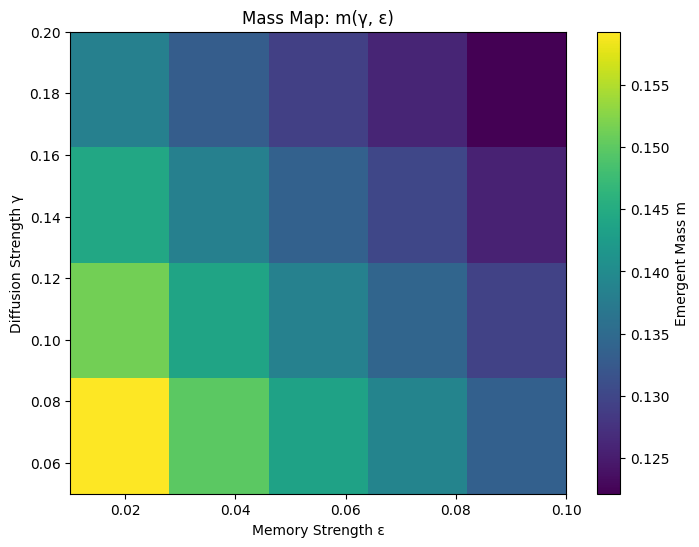

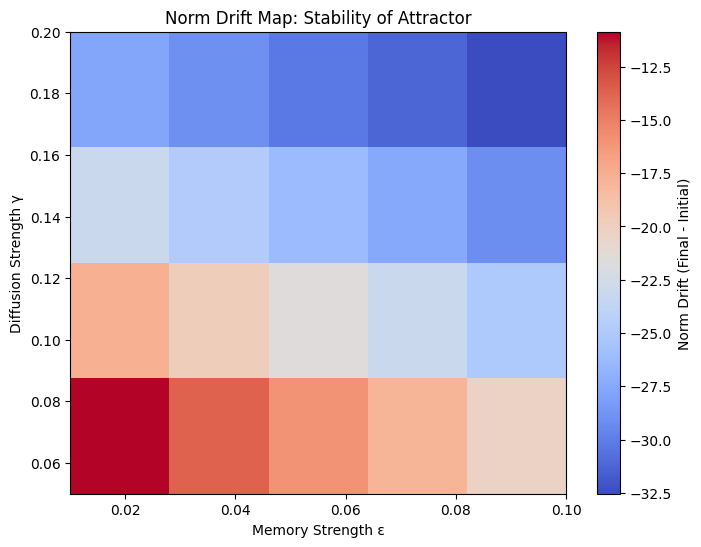

In [ ]:
# QFT007: Mass Fidelity Scan — Emergent Mass Stability Across HES Parameters
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Parameters
N = 100
T = 100
A = 1.0
sigma = 5.0
gamma_vals = [0.05, 0.1, 0.15, 0.2]
epsilon_vals = [0.01, 0.03, 0.05, 0.07, 0.1]

# Storage
mass_map = np.zeros((len(gamma_vals), len(epsilon_vals)))
norm_drift = np.zeros_like(mass_map)

# Decay fit function
def decay_func(r, a, lambda_c):
    return a * np.exp(-r / lambda_c)

# Simulation loop
for i, gamma in enumerate(gamma_vals):
    for j, epsilon in enumerate(epsilon_vals):
        # Initialize ψ
        x0, y0 = N//2, N//2
        X, Y = np.meshgrid(np.arange(N), np.arange(N))
        psi = A * np.exp(-((X - x0)**2 + (Y - y0)**2) / (2 * sigma**2)) + 1j * np.zeros((N, N))
        norms = []

        # Evolve
        for t in range(T):
            psi_new = np.copy(psi)
            for x in range(N):
                for y in range(N):
                    xp, xm = (x+1)%N, (x-1)%N
                    yp, ym = (y+1)%N, (y-1)%N

                    # 9-point Laplacian
                    laplacian = (
                        (psi[xp,y] + psi[xm,y] + psi[x,yp] + psi[x,ym]) / 6 +
                        (psi[xp,yp] + psi[xp,ym] + psi[xm,yp] + psi[xm,ym]) / 12 -
                        psi[x,y]
                    )
                    diffusion = gamma * laplacian

                    # Symmetric memory compensation
                    delta_A2 = (
                        np.abs(psi[xp,y])**2 + np.abs(psi[xm,y])**2 - 2 * np.abs(psi[x,y])**2
                    )
                    compensation = epsilon * delta_A2

                    psi_new[x,y] = psi[x,y] + diffusion + compensation
            psi = psi_new
            norms.append(np.sum(np.abs(psi)**2))

        # Extract radial profile
        magnitude = np.abs(psi)**2
        radii = []
        values = []
        for r in range(1, N//2):
            shell = magnitude[x0-r:x0+r+1, y0-r:y0+r+1]
            shell_mean = np.mean(shell)
            radii.append(r)
            values.append(shell_mean)

        try:
            params, _ = curve_fit(decay_func, radii, values, p0=(1.0, 10.0))
            lambda_c = params[1]
            mass = 1 / lambda_c
        except:
            lambda_c = np.nan
            mass = np.nan

        mass_map[i, j] = mass
        norm_drift[i, j] = norms[-1] - norms[0]

# Plot mass heatmap
plt.figure(figsize=(8, 6))
plt.imshow(mass_map, cmap='viridis', origin='lower', extent=[min(epsilon_vals), max(epsilon_vals), min(gamma_vals), max(gamma_vals)], aspect='auto')
plt.colorbar(label='Emergent Mass m')
plt.xlabel('Memory Strength ε')
plt.ylabel('Diffusion Strength γ')
plt.title('Mass Map: m(γ, ε)')
plt.show()

# Plot norm drift heatmap
plt.figure(figsize=(8, 6))
plt.imshow(norm_drift, cmap='coolwarm', origin='lower', extent=[min(epsilon_vals), max(epsilon_vals), min(gamma_vals), max(gamma_vals)], aspect='auto')
plt.colorbar(label='Norm Drift (Final - Initial)')
plt.xlabel('Memory Strength ε')
plt.ylabel('Diffusion Strength γ')
plt.title('Norm Drift Map: Stability of Attractor')
plt.show()


In [ ]:
# Calculate approximate percentage completion
total_iterations = len(gamma_vals) * len(epsilon_vals) * T
current_iteration = (i * len(epsilon_vals) * T) + (j * T) + t + 1
percentage_complete = (current_iteration / total_iterations) * 100

print(f"Approximately {percentage_complete:.2f}% of the simulation loop is complete.")